In [ ]:
import random
import math
from ml_dtypes import bfloat16

class Value:

  def __init__(self, data, _children = (), _op = '', label = ''):
    self.data = data
    self._prev = set(_children)
    self.grad = 0.00
    self._backwards = None
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data = {self.data})"

  def __add__(self, other):

    other = other if(isinstance(other, Value)) else Value(other)
    out = Value(self.data + other.data, (self, other), "+")

    def _backwards():
      self.grad += out.grad
      other.grad += out.grad

    out._backwards = _backwards

    return out

  def __radd__(self, other):
    return self+other

  def __neg__(self):
    return self * -1

  def __sub__(self, other):
    return self + (-other)

  def __mul__(self, other):

    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), "*")

    def _backwards():
      self.grad += out.grad*other.data
      other.grad += out.grad*self.data

    out._backwards = _backwards
    return out

  def __rmul__(self, other):
    return self*other

  def __truediv__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    return self*(other**-1)

  def exp(self):

    out = Value(math.exp(self.data), (self,), "exp")

    def _backwards():
      self.grad += out.data*out.grad

    out._backwards = _backwards
    return out

  def __pow__(self, other):

    assert(isinstance(other, int))

    out = Value(self.data**other, (self,), f"**{other}")

    def _backwards():
      self.grad += other*(self.data**(other-1))*out.grad

    out._backwards = _backwards
    return out

  def tanh(self):

    x = (math.exp(2*self.data) - 1)/(math.exp(2*self.data) + 1)
    out = Value(x ,(self, ), 'tanh')

    def _backwards():
      self.grad += (1 - x**2)*out.grad

    out._backwards = _backwards
    return out

  def ReLU(self):

    x = self.data if self.data > 0 else 0
    out = Value(x, (self, ), "ReLU")

    def _backwards():
      self.grad += out.grad if self.data > 0 else 0

    out._backwards = _backwards
    return out

  def sigmoid(self):

    x = 1/(1+math.exp(self.data*-1))
    out = Value(x, (self, ), "sigmoid")

    def _backwards():
      self.grad += x*(1-x)*out.grad

    out._backwards = _backwards
    return out

  def backward(self):
    topo = []
    visited = set()

    def build(v):
        if v not in visited:
            visited.add(v)
            for child in v._prev:
                build(child)
            topo.append(v)

    build(self)
    self.grad = 1.0

    for v in reversed(topo):
      if v._backwards:
        v._backwards()

class Tensor:

  def __init__(self, data, _children=(), _op='', requires_grad=False):
    self.data=np.array(data, dtype=np.float64)
    self.requires_grad=requires_grad
    self._prev=set(_children)
    self._op=_op
    self.grad = np.zeros_like(self.data) if requires_grad else None
    self._backward = lambda: None

  def __repr__(self):
    return f"Tensor(data = {self.data}, shape = {self.data.shape}, requires_grad = {self.requires_grad})"

  def __add__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data + other.data, (self, other), '+', requires_grad=self.requires_grad or other.requires_grad)

    def _backward():
        if out.grad is None: return
        if self.requires_grad:
            grad_self = out.grad
            while grad_self.ndim > self.data.ndim:
                grad_self = grad_self.sum(axis=0)
            for i, dim in enumerate(self.data.shape):
                if dim == 1:
                    grad_self = grad_self.sum(axis=i, keepdims=True)
            self.grad += grad_self

        if other.requires_grad:
            grad_other = out.grad
            while grad_other.ndim > other.data.ndim:
                grad_other = grad_other.sum(axis=0)
            for i, dim in enumerate(other.data.shape):
                if dim == 1:
                    grad_other = grad_other.sum(axis=i, keepdims=True)
            other.grad += grad_other

    out._backward = _backward
    return out

  def __radd__(self, other):
    return self+other

  def __neg__(self):
    return self * (-1.0)

  def __sub__(self, other):
    return self + (-other)

  def __matmul__(self, other):
    out = Tensor(self.data @ other.data, (self, other), '@', requires_grad=self.requires_grad or other.requires_grad)

    def _backward():
        if out.grad is None: return

        if self.requires_grad:
            self.grad += out.grad @ other.data.T

        if other.requires_grad:
            other.grad += self.data.T @ out.grad

    out._backward = _backward
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Tensor) else Tensor(other)
    out = Tensor(self.data * other.data, (self, other), '*', requires_grad=self.requires_grad or other.requires_grad)

    def _backward():
        if out.grad is None: return
        if self.requires_grad:
            self.grad += other.data * out.grad
        if other.requires_grad:
            grad_other = self.data * out.grad
            while grad_other.ndim > other.data.ndim:
                grad_other = grad_other.sum(axis=0)
            other.grad += grad_other
    out._backward = _backward
    return out

  def __rmul__(self, other):
    return self * other

  def __rmatmul__(self, other):
    return self @ other

  def __truediv__(self, other):
    return self*(other**-1)

  def __pow__(self, other):
    assert isinstance(other, (int, float))
    out = Tensor(self.data**other, (self, ), '**', requires_grad=self.requires_grad or other.requires_grad)

    def _backward():
      if self.requires_grad:
        self.grad += other*(self.data**(other-1))*out.grad

    out._backward = _backward
    return out

  def exp(self):
    t = np.exp(self.data)
    out = Tensor(t, (self, ), 'exp', requires_grad=self.requires_grad)

    def _backward():
      if self.requires_grad:
        self.grad += t*out.grad

    out._backward = _backward
    return out

  def log(self):
    t = np.log(self.data + 1e-15)
    out = Tensor(t, (self, ), 'log', requires_grad=self.requires_grad)

    def _backward():
      if self.requires_grad:
        self.grad += (1/(self.data + 1e-15))*out.grad

    out._backward = _backward
    return out

  def tanh(self):
    t = np.tanh(self.data)
    out = Tensor(t, (self, ), 'tanh', requires_grad=self.requires_grad)

    def _backward():
      if self.requires_grad:
        self.grad += (1 - t**2)*out.grad

    out._backward = _backward
    return out

  def ReLU(self):
    out = Tensor(np.maximum(0, self.data), (self, ), 'ReLU', requires_grad=self.requires_grad)
    mask = (self.data > 0)

    def _backward():
      if self.requires_grad:
        self.grad += mask * out.grad

    out._backward = _backward
    return out

  def sigmoid(self):
    t = 1 / (1 + np.exp(-self.data))
    out = Tensor(t, (self, ), 'sigmoid', requires_grad=self.requires_grad)

    def _backward():
      if self.requires_grad:
        self.grad += t*(1 - t) * out.grad

    out._backward = _backward
    return out

  def softmax(self):
    e = np.exp(self.data - self.data.max(axis=1, keepdims=True))
    t = e / e.sum(axis=1, keepdims=True)
    out = Tensor(t, (self,), 'softmax', requires_grad=self.requires_grad)

    def _backward():
        if self.requires_grad:
            dx = t * (out.grad - (out.grad * t).sum(axis=1, keepdims=True))
            self.grad += dx

    out._backward = _backward
    return out

  def mean(self):
    out = Tensor(np.mean(self.data), (self,), 'mean', requires_grad=self.requires_grad)
    def _backward():
        if self.requires_grad:
            self.grad += (np.ones_like(self.data) / self.data.size) * out.grad
    out._backward = _backward
    return out

  def backward(self):
    topo = []
    visited = set()

    def build_topo(v):
        if v not in visited:
            visited.add(v)
            for child in v._prev:
                build_topo(child)
            topo.append(v)

    build_topo(self)
    self.grad = np.ones_like(self.data)

    for n in reversed(topo):
      n._backward()

class Linear:

  def __init__(self, nin, nout):
    self.weight=Tensor(np.random.randn(nin, nout) * np.sqrt(2.0 / nin), requires_grad=True)
    self.bias=Tensor(np.zeros((1, nout)), requires_grad=True)

  def __call__(self, x):
    return x @ self.weight + self.bias

  def parameters(self):
    return [self.weight, self.bias]

class MLP:

  def __init__(self, nin, nouts):
    self.layers= [nin] + nouts
    self.linears=[Linear(self.layers[i], self.layers[i+1]) for i in range(len(self.layers)-1)]

  def __call__(self, x):
    for i, layer in enumerate(self.linears):
      x = layer(x)
      if i == len(self.linears) - 1:
        x = x.softmax()
      else:
        x = x.ReLU()
    return x

  def parameters(self):
    return [p for layer in self.linears for p in layer.parameters()]

class ResidualBlock:

  def __init__(self, dim):
    self.lin1 = Linear(dim, dim)
    self.lin2 = Linear(dim, dim)

  def __call__(self, x):

    skip = x
    x.data = cast_low(x.data)
    h = self.lin1(x)
    h = h.ReLU()
    h.data = cast_low(h.data)
    h = self.lin2(h)

    return (h + skip).ReLU()

  def parameters(self):
    return self.lin1.parameters() + self.lin2.parameters()

class ResidualMLP:

  def __init__(self, nin, hidden_dim, n_blocks, nout):

    self.input_projection = Linear(nin, hidden_dim)
    self.blocks = [ResidualBlock(hidden_dim) for n in range(n_blocks)]
    self.output_projection = Linear(hidden_dim, nout)

  def __call__(self, x):

    x = self.input_projection(x).ReLU()

    for block in self.blocks:
      x = block(x)

    x = self.output_projection(x)
    return x.softmax()

  def parameters(self):

    params = self.input_projection.parameters()

    for block in self.blocks:
      params += block.parameters()

    params += self.output_projection.parameters()
    return params

class Adam:

  def __init__(self, params, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=0.001):
    self.params=params
    self.lr=lr
    self.weight_decay=weight_decay
    self.beta1=beta1
    self.beta2=beta2
    self.eps=eps

    self.t = 0
    self.m = {id(p): np.zeros_like(p.data) for p in params}
    self.v = {id(p): np.zeros_like(p.data) for p in params}

  def step(self):
    self.t+=1

    for p in self.params:
      if p.grad is None:
        continue

      pid = id(p)
      self.m[pid] = self.beta1 * self.m[pid] + (1 - self.beta1) * p.grad
      self.v[pid] = self.beta2 * self.v[pid] + (1 - self.beta2) * p.grad * p.grad

      m_hat = self.m[pid] / (1 - self.beta1**self.t)
      v_hat = self.v[pid] / (1 - self.beta2**self.t)

      p.data -= self.lr * (m_hat / (np.sqrt(v_hat) + self.eps) + self.weight_decay * p.data)

  def zero_grad(self):
    for p in self.params:
      p.grad = np.zeros_like(p.data)

def cross_entropy(y_pred, y_true, num_classes):

    Y_onehot = Tensor(np.eye(num_classes)[y_true])
    loss = -(Y_onehot * y_pred.log()).mean() * num_classes
    return loss

def cast_low(x):
    return x.astype(bfloat16).astype(np.float64)

In [ ]:
import zipfile, os
from google.colab import drive
drive.mount('/content/drive')

zip_path = "/content/drive/MyDrive/datasets/archive (1).zip"

# Peek inside first
with zipfile.ZipFile(zip_path, 'r') as z:
    print("Files in zip:")
    for name in z.namelist():
        print(f"  {name}")

# Extract
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall("/content/sign_data")
print("\nExtracted to /content/sign_data")
print(os.listdir("/content/sign_data"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files in zip:
  amer_sign2.png
  amer_sign3.png
  american_sign_language.PNG
  sign_mnist_test.csv
  sign_mnist_test/sign_mnist_test.csv
  sign_mnist_train.csv
  sign_mnist_train/sign_mnist_train.csv

Extracted to /content/sign_data
['amer_sign2.png', 'sign_mnist_test.csv', 'sign_mnist_train', 'sign_mnist_train.csv', 'amer_sign3.png', 'sign_mnist_test', 'american_sign_language.PNG']


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np

print("Loading Sign Language MNIST")

train_df = pd.read_csv("/content/sign_data/sign_mnist_train.csv")
test_df = pd.read_csv("/content/sign_data/sign_mnist_test.csv")

df = pd.concat([train_df, test_df], ignore_index=True)
X_raw = df.drop("label", axis=1).values.astype(np.float64)
y_raw = df["label"].values.astype(int)

X_flat = X_raw / 255.0

print(f"Shape for features is {X_flat.shape}")   # expect (34627, 784)
print(f"Shape for target is   {y_raw.shape}")
print(f"Min={X_flat.min():.2f}  Max={X_flat.max():.2f}  Mean={X_flat.mean():.4f}")

X_train, X_temp, Y_train, Y_temp = train_test_split(X_flat, y_raw, random_state=42, test_size=0.3)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, random_state=42, test_size=0.5)

print(f"\nTrain: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Loading Sign Language MNIST
Shape for features is (34627, 784)
Shape for target is   (34627,)
Min=0.00  Max=1.00  Mean=0.6257

Train: (24238, 784), Val: (5194, 784), Test: (5195, 784)


In [ ]:
from tqdm import tqdm

num_classes = 25

def train(learning_rate, batch_size, epochs):

  print(f"Currently running for Learning Rate = {learning_rate} and Batch Size = {batch_size}")

  model = ResidualMLP(nin=784, hidden_dim=128, n_blocks=3, nout=num_classes)
  optimizer = Adam(model.parameters(), lr=learning_rate, weight_decay=0.001)

  train_losses = []
  val_accuracies = []

  for epoch in range(epochs):

      total_loss = 0
      num_batches = 0

      for i in tqdm(range(0, len(X_train), batch_size), desc=f"Epoch {epoch+1}/{epochs}"):

        X_batch = Tensor(X_train[i : i + batch_size])
        Y_batch = Y_train[i : i + batch_size]

        optimizer.zero_grad()

        y_pred = model(X_batch)
        loss = cross_entropy(y_pred, Y_batch, num_classes)

        loss.backward()
        optimizer.step()

        total_loss += loss.data
        num_batches += 1

      average_loss = total_loss / num_batches
      train_losses.append(average_loss)

      correct = 0

      for i in range(0, len(X_val), batch_size):

        X_batch = Tensor(X_val[i : i + batch_size])
        Y_batch = Y_val[i : i + batch_size]

        y_pred = model(X_batch)
        preds = np.argmax(y_pred.data, axis = 1)

        correct += (preds == Y_batch).sum()

      val_acc = correct / len(X_val)
      val_accuracies.append(val_acc)

      print(f"Epoch {epoch+1}: loss = {average_loss:.4f}, val accuracy = {val_acc*100:.2f}%")

  return model, train_losses, val_accuracies

def test(model, batch_size):

  correct = 0

  for i in range(0, len(X_test), batch_size):

    X_batch = Tensor(X_test[i : i + batch_size])
    Y_batch = Y_test[i : i + batch_size]

    y_pred = model(X_batch)
    preds = np.argmax(y_pred.data, axis = 1)

    correct += (preds == Y_batch).sum()

  test_acc = correct / len(X_test)
  print(f"Test Accuracy is {test_acc}")

  return test_acc

In [ ]:
best_accuracy = 0
best_lr = 0
best_batch = 0
results = []

learning_rates = [0.0005, 0.001, 0.003]
batch_sizes = [16, 64, 128]

for lr in learning_rates:
  for batch in batch_sizes:
    model, losses, accs = train(lr, batch, 10)
    accuracy = test(model, batch)

    results.append({
      'lr': lr,
      'batch': batch,
      'losses': losses,
      'val_accs': accs,
      'test_acc': accuracy
    })

    if accuracy > best_accuracy:
      best_accuracy = accuracy
      best_lr = lr
      best_batch = batch

Currently running for Learning Rate = 0.0005 and Batch Size = 16


Epoch 1/10: 100%|██████████| 1515/1515 [00:17<00:00, 86.24it/s] 


Epoch 1: loss = 1.7364, val accuracy = 69.66%


Epoch 2/10: 100%|██████████| 1515/1515 [00:17<00:00, 85.29it/s] 


Epoch 2: loss = 0.6905, val accuracy = 81.00%


...

Epoch 8: loss = 0.1833, val accuracy = 94.13%


Epoch 9/10: 100%|██████████| 190/190 [00:03<00:00, 57.69it/s]


Epoch 9: loss = 0.1432, val accuracy = 95.53%


Epoch 10/10: 100%|██████████| 190/190 [00:06<00:00, 28.18it/s]


Epoch 10: loss = 0.2470, val accuracy = 97.29%
Test Accuracy is 0.9734359961501444


In [ ]:
print(f"The best accuracy is {best_accuracy}, which is achieved with Learning Rate = {best_lr} and Batch Size = {best_batch}")

The best accuracy is 0.9932627526467758, which is achieved with Learning Rate = 0.0005 and Batch Size = 16


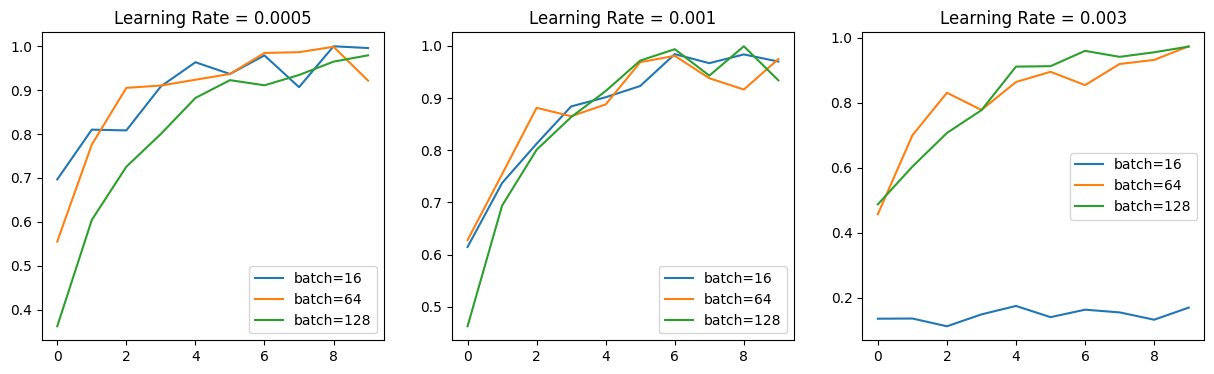

In [ ]:
import matplotlib.pyplot as plt

learning_rates = [0.0005, 0.001, 0.003]
batch_sizes = [16, 64, 128]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, lr in enumerate(learning_rates):

    ax = axes[i]
    ax.set_title(f"Learning Rate = {lr}")

    for result in results:
        if result["lr"] == lr:
            ax.plot(result["val_accs"], label=f"batch={result['batch']}")

    ax.legend()

plt.show()